<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Machine-Learning/blob/main/Loan_Approved_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [348]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [349]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [350]:
df=pd.read_csv("/content/drive/MyDrive/loan_data.csv")

In [351]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [352]:
df.shape

(45000, 14)

In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [354]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [355]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [356]:
df.duplicated().sum()

np.int64(0)

In [357]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [358]:
# Remove Unnesssary Colums
df=df.drop(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership'],axis=1)

In [359]:
df.head()

,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [360]:
df.isnull().sum()

,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
previous_loan_defaults_on_file,0
loan_status,0


In [361]:
df.dropna(inplace=True)

In [362]:
df.head()

,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [363]:
df.isnull().sum()

,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
previous_loan_defaults_on_file,0
loan_status,0


In [364]:
df.rename(columns={"loan_amnt":"Loan Amount",	"loan_intent":"Loan Intent","loan_int_rate":"Loan interest Rate","loan_percent_income":"Loan percentage","cb_person_cred_hist_length":"Credit History",	"credit_score":"Credit Score","previous_loan_defaults_on_file":"Previous Loan",	"loan_status":"Loan Status"},inplace=True)

In [365]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [366]:
df.dtypes

,0
Loan Amount,float64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64
Credit History,float64
Credit Score,int64
Previous Loan,object
Loan Status,int64


In [367]:
df['Credit History']=df['Credit History'].astype(int)

In [368]:
df['Credit History'].dtype

dtype('int64')

#Check Unique Values of All Columns.

In [369]:
df['Credit History'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [370]:
df['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [371]:
df['Loan Intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [372]:
df['Loan Amount'].unique()

array([35000.,  1000.,  5500., ..., 12229.,  2771.,  6665.])

In [373]:
df['Loan Status'].unique()

array([1, 0])

In [374]:
df['Loan percentage'].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [375]:
df['Previous Loan'].unique()

array(['No', 'Yes'], dtype=object)

In [376]:
df['Loan interest Rate'].unique()

array([16.02, 11.14, 12.87, ..., 19.11, 19.8 , 16.92])

#Train-Test-Split

In [377]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [378]:
x=df.drop('Loan Status',axis=1)
y=df['Loan Status']

In [379]:
x

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
0,35000.0,PERSONAL,16.02,0.49,3,561,No
1,1000.0,EDUCATION,11.14,0.08,2,504,Yes
2,5500.0,MEDICAL,12.87,0.44,3,635,No
3,35000.0,MEDICAL,15.23,0.44,2,675,No
4,35000.0,MEDICAL,14.27,0.53,4,586,No
...,...,...,...,...,...,...,...
44995,15000.0,MEDICAL,15.66,0.31,3,645,No
44996,9000.0,HOMEIMPROVEMENT,14.07,0.14,11,621,No
44997,2771.0,DEBTCONSOLIDATION,10.02,0.05,10,668,No
44998,12000.0,EDUCATION,13.23,0.36,6,604,No


In [380]:
y

,Loan Status
0,1
1,0
2,1
3,1
4,1
...,...
44995,1
44996,1
44997,1
44998,1


In [381]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [382]:
ohe=OneHotEncoder(drop='first')

In [383]:
new_data=ohe.fit_transform(df[['Loan Intent']]).toarray()

In [384]:
new_data.shape

(45000, 5)

In [385]:
df['Loan Intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [386]:
df1=pd.DataFrame(new_data,columns=ohe.get_feature_names_out())

In [387]:
df=pd.concat([df,df1],axis=1)

In [388]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
0,35000.0,PERSONAL,16.02,0.49,3,561,No,1,0.0,0.0,0.0,1.0,0.0
1,1000.0,EDUCATION,11.14,0.08,2,504,Yes,0,1.0,0.0,0.0,0.0,0.0
2,5500.0,MEDICAL,12.87,0.44,3,635,No,1,0.0,0.0,1.0,0.0,0.0
3,35000.0,MEDICAL,15.23,0.44,2,675,No,1,0.0,0.0,1.0,0.0,0.0
4,35000.0,MEDICAL,14.27,0.53,4,586,No,1,0.0,0.0,1.0,0.0,0.0


#Label Encoding

In [389]:
from sklearn.preprocessing import LabelEncoder

In [390]:
le=LabelEncoder()

In [391]:
df['Previous Loan']=le.fit_transform(df['Previous Loan'])

In [392]:
df['Previous Loan']

,Previous Loan
0,0
1,1
2,0
3,0
4,0
...,...
44995,0
44996,0
44997,0
44998,0


#Data Scaling

In [393]:
num_cols = [
    'Loan Amount',
    'Loan interest Rate',
    'Loan percentage',
    'Credit Score',
    'Credit History'
]





In [394]:
from sklearn.preprocessing import StandardScaler


In [395]:
scaler = StandardScaler()


In [396]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




In [397]:

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])


In [398]:
x_train

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
25180,0.859025,PERSONAL,0.577910,0.119054,0.816732,-0.032444,No
12555,0.383393,VENTURE,0.286925,0.233921,-0.478914,0.524687,Yes
29153,2.285919,PERSONAL,-0.211430,-0.799885,1.334990,1.002227,Yes
23838,0.002888,EDUCATION,2.052907,-0.455283,0.298474,0.166531,No
35686,-0.399971,HOMEIMPROVEMENT,0.658182,-0.685018,-0.738043,1.459871,Yes
...,...,...,...,...,...,...,...
11284,0.165396,EDUCATION,-1.663014,-0.225548,-0.478914,-1.465066,Yes
44732,-0.587529,HOMEIMPROVEMENT,0.230066,0.348788,-0.478914,0.285916,No
38158,0.178396,VENTURE,-0.087677,0.463655,0.816732,0.385404,Yes
860,1.651744,DEBTCONSOLIDATION,2.337203,-0.340416,-0.738043,-0.569677,No


In [399]:
x_test

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
37979,-0.330054,EDUCATION,-1.659669,-0.685018,1.075861,-0.629370,No
9911,-0.092238,EDUCATION,0.163172,0.233921,-0.478914,0.285916,Yes
43386,-0.726413,MEDICAL,1.297013,-0.110681,-0.478914,1.559358,No
13822,-0.726413,VENTURE,0.999338,-0.110681,-0.738043,-0.708960,Yes
44810,0.066306,HOMEIMPROVEMENT,1.474280,0.119054,1.334990,-0.927833,No
...,...,...,...,...,...,...,...
14572,0.700481,VENTURE,-0.338527,-0.340416,-0.997172,0.425199,No
30384,-0.452925,EDUCATION,1.822125,-0.340416,1.334990,-0.529882,Yes
36665,0.700481,EDUCATION,0.216687,0.463655,-0.738043,-0.370702,No
30569,-0.250782,MEDICAL,0.002628,0.923125,2.112377,1.240998,No


In [400]:
df.corr(numeric_only=True)

,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
Loan Amount,1.000000,0.146093,0.593011,0.042969,0.009074,-0.059009,0.107714,-0.006062,0.045657,-0.034140,0.001476,0.005500
Loan interest Rate,0.146093,1.000000,0.125209,0.018008,0.011498,-0.181800,0.332005,-0.017332,0.022505,0.012609,-0.004051,-0.013177
Loan percentage,0.593011,0.125209,1.000000,-0.031868,-0.011483,-0.203252,0.384880,-0.001033,-0.015604,0.020547,-0.007713,0.001601
Credit History,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.022640,-0.014851,-0.070653,0.054821,0.013298,0.027952,-0.004942
Credit Score,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.183005,-0.007647,-0.015508,0.010228,0.003359,0.003795,0.009705
Previous Loan,-0.059009,-0.181800,-0.203252,-0.022640,-0.183005,1.000000,-0.543096,0.038725,-0.021713,-0.034562,0.004153,0.052122
Loan Status,0.107714,0.332005,0.384880,-0.014851,-0.007647,-0.543096,1.000000,-0.064006,0.033838,0.065195,-0.022488,-0.085992
Loan Intent_EDUCATION,-0.006062,-0.017332,-0.001033,-0.070653,-0.015508,0.038725,-0.064006,1.000000,-0.174261,-0.244696,-0.226920,-0.231724
Loan Intent_HOMEIMPROVEMENT,0.045657,0.022505,-0.015604,0.054821,0.010228,-0.021713,0.033838,-0.174261,1.000000,-0.167000,-0.154868,-0.158147
Loan Intent_MEDICAL,-0.034140,0.012609,0.020547,0.013298,0.003359,-0.034562,0.065195,-0.244696,-0.167000,1.000000,-0.217464,-0.222068


<Axes: >

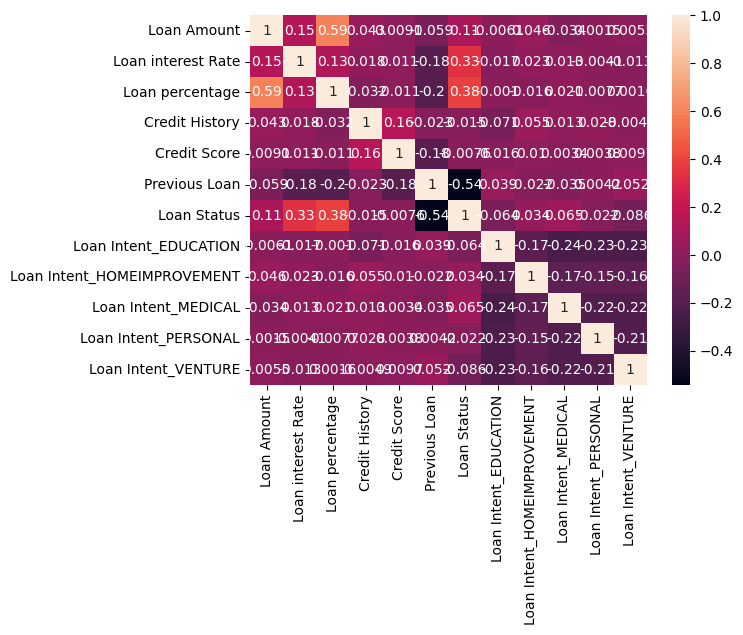

In [401]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [402]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
0,35000.0,PERSONAL,16.02,0.49,3,561,0,1,0.0,0.0,0.0,1.0,0.0
1,1000.0,EDUCATION,11.14,0.08,2,504,1,0,1.0,0.0,0.0,0.0,0.0
2,5500.0,MEDICAL,12.87,0.44,3,635,0,1,0.0,0.0,1.0,0.0,0.0
3,35000.0,MEDICAL,15.23,0.44,2,675,0,1,0.0,0.0,1.0,0.0,0.0
4,35000.0,MEDICAL,14.27,0.53,4,586,0,1,0.0,0.0,1.0,0.0,0.0


In [403]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
0,35000.0,PERSONAL,16.02,0.49,3,561,0,1,0.0,0.0,0.0,1.0,0.0
1,1000.0,EDUCATION,11.14,0.08,2,504,1,0,1.0,0.0,0.0,0.0,0.0
2,5500.0,MEDICAL,12.87,0.44,3,635,0,1,0.0,0.0,1.0,0.0,0.0
3,35000.0,MEDICAL,15.23,0.44,2,675,0,1,0.0,0.0,1.0,0.0,0.0
4,35000.0,MEDICAL,14.27,0.53,4,586,0,1,0.0,0.0,1.0,0.0,0.0


In [404]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
0,35000.0,PERSONAL,16.02,0.49,3,561,0,1,0.0,0.0,0.0,1.0,0.0
1,1000.0,EDUCATION,11.14,0.08,2,504,1,0,1.0,0.0,0.0,0.0,0.0
2,5500.0,MEDICAL,12.87,0.44,3,635,0,1,0.0,0.0,1.0,0.0,0.0
3,35000.0,MEDICAL,15.23,0.44,2,675,0,1,0.0,0.0,1.0,0.0,0.0
4,35000.0,MEDICAL,14.27,0.53,4,586,0,1,0.0,0.0,1.0,0.0,0.0


In [405]:
df.dtypes

,0
Loan Amount,float64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64
Credit History,int64
Credit Score,int64
Previous Loan,int64
Loan Status,int64
Loan Intent_EDUCATION,float64
Loan Intent_HOMEIMPROVEMENT,float64


In [406]:
from sklearn.compose import make_column_transformer

In [407]:
scaler.fit(x[['Loan Amount','Loan interest Rate','Loan percentage','Credit Score','Credit History']])

StandardScaler()

In [408]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(x[['Loan Intent']])

In [409]:
le.fit(x['Previous Loan'])

LabelEncoder()

In [410]:
df['Previous Loan']=le.fit_transform(df['Previous Loan'])

In [411]:

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Loan Intent'])
)


In [412]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

columns_trans = make_column_transformer(
    (OneHotEncoder(drop='first', sparse_output=False), ['Loan Intent']),
    (OrdinalEncoder(categories=[['No', 'Yes']]), ['Previous Loan']),
    (StandardScaler(), [
        'Loan Amount',
        'Loan interest Rate',
        'Loan percentage',
        'Credit Score',
        'Credit History'
    ]),
    remainder='passthrough'
)


In [413]:
columns_trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Loan Intent']),
                                ('ordinalencoder',
                                 OrdinalEncoder(categories=[['No', 'Yes']]),
                                 ['Previous Loan']),
                                ('standardscaler', StandardScaler(),
                                 ['Loan Amount', 'Loan interest Rate',
                                  'Loan percentage', 'Credit Score',
                                  'Credit History'])])

In [414]:
x_train_transform = columns_trans.fit_transform(x_train)
x_test_transform = columns_trans.transform(x_test)


In [415]:
feature_names = columns_trans.get_feature_names_out()

x_train_transform = pd.DataFrame(
    x_train_transform,
    columns=feature_names
)

x_test_transform = pd.DataFrame(
    x_test_transform,
    columns=feature_names
)


In [416]:
# Linear Regression Models
from sklearn.linear_model import LinearRegression

# Tree-Based Regression Models
from sklearn.tree import DecisionTreeRegressor

# Distance / Kernel-Based Models
from sklearn.neighbors import KNeighborsRegressor


#Boosting
from lightgbm import LGBMRegressor

In [417]:

# Objects of Models

lr   = LinearRegression()
dt   = DecisionTreeRegressor()
knn  = KNeighborsRegressor()
lgbm = LGBMRegressor()

In [418]:
regressors={
    "LR":lr,
    "DT":dt,
    "KNN":knn,
    "LGBM":lgbm
}



In [419]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [420]:

def train_regessor(regressors,x_train,x_test,y_train,y_test,name):
  # Train The Regressor
  regressors.fit(x_train,y_train)
  # Make Prediction
  y_pred=regressors.predict(x_test)

  # Calculate metrics
  mse=mean_squared_error(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)
  return mse,mae,r2


In [421]:
mse_scores = []
mae_scores = []
r2_scores = []

for name, reg in regressors.items():
    current_mse, current_mae, current_r2 = train_regessor(
        reg, x_train_transform, x_test_transform, y_train, y_test, name
    )

    print(f'Name: {name}')
    print(f'MSE: {current_mse}')
    print(f'MAE: {current_mae}')
    print(f'R2: {current_r2}')
    print('----------------------------')

    mse_scores.append(current_mse)
    mae_scores.append(current_mae)
    r2_scores.append(current_r2)

Name: LR
MSE: 0.09487266753237546
MAE: 0.24584112267837357
R2: 0.4530433618657489
----------------------------
Name: DT
MSE: 0.13011111111111112
MAE: 0.13011111111111112
R2: 0.24988789955800372
----------------------------
Name: KNN
MSE: 0.07920000000000002
MAE: 0.13875555555555552
R2: 0.5433988854013193
----------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 11
[LightGBM] [Info] Start training from score 0.221944
Name: LGBM
MSE: 0.06321943269236939
MAE: 0.131547785286131
R2: 0.6355295021258569
----------------------------


In [422]:
print(df['Previous Loan'].isna().sum())


0


In [423]:
from sklearn.pipeline import make_pipeline

In [424]:
pipe1=make_pipeline(columns_trans,lr)
pipe2=make_pipeline(columns_trans,dt)
pipe3=make_pipeline(columns_trans,knn)
pipe4=make_pipeline(columns_trans,lgbm)

In [425]:
pipe1.fit(x_train,y_train)
pipe2.fit(x_train,y_train)
pipe3.fit(x_train,y_train)
pipe4.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 11
[LightGBM] [Info] Start training from score 0.221944


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Loan Intent']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  ['Previous Loan']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  ['Loan Amount',
                                                   'Loan interest Rate',
                                                   'Loan percentage',
                                                   'Credit Score',
                                                   'Credit History'])])),
                ('lgbmregressor', LGBMRegressor())])

In [426]:

y_pred_pipe1=pipe1.predict(x_test)
y_pred_pipe2=pipe2.predict(x_test)
y_pred_pipe3=pipe3.predict(x_test)
y_pred_pipe4=pipe4.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [427]:
print(r2_score(y_test,y_pred_pipe1))
print(r2_score(y_test,y_pred_pipe2))
print(r2_score(y_test,y_pred_pipe3))
print(r2_score(y_test,y_pred_pipe4))

0.4530433618657489
0.24027929024405836
0.5433988854013193
0.6355295021258569


In [428]:
scores=[]
for i in range(1000):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=i)
    lgbm = LGBMRegressor()
    pipe=make_pipeline(columns_trans,lgbm)
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    scores.append(r2_score(y_test,y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 838
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 11
[LightGBM] [Info] Start training from score 0.222593


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 838
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 11
[LightGBM] [Info] Start training from score 0.220988


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 839
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 11
[LightGBM] [Info] Start training from score 0.222198


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 840
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 11
[LightGBM] [Info] Start training from score 0.220543


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 11
[LightGBM] [Info] Start training from score 0.221951


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [429]:
np.argmax(scores)

np.int64(545)

In [436]:
scores[np.argmax(scores)]

0.6753906865962094

In [437]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=np.argmax(scores))
lgbm= LGBMRegressor()
pipe=make_pipeline(columns_trans,lgbm)
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)
r2_score(y_test,y_pred)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 11
[LightGBM] [Info] Start training from score 0.221500


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.6541633861213483